# WiDS Datathon 2025: Final submission

# Project Objectives

# Data

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import linkage
import random
from sklearn.decomposition import PCA
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

#qm_data_path = "./widsdatathon2025/TRAIN/TRAIN_QUANTITATIVE_METADATA.xlsx"
qm_data_path = "./widsdatathon2025/TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx"
fcm_data_path = "./widsdatathon2025/TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv"
cm_data_path = "./widsdatathon2025/TRAIN_NEW/TRAIN_CATEGORICAL_METADATA_new.xlsx"

y = pd.read_excel("./widsdatathon2025/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")



qm_df = pd.read_excel(qm_data_path)
fcm_df = pd.read_csv(fcm_data_path) #this is kinda big, hopefully we can process it a bit and create a new reduced file to load
cm_df = pd.read_excel(cm_data_path)
print(qm_df.shape)
print(fcm_df.shape)
print(cm_df.shape)

(1213, 19)
(1213, 19901)
(1213, 10)


In [3]:
print(qm_df.describe())

       EHQ_EHQ_Total  ColorVision_CV_Score  APQ_P_APQ_P_CP  APQ_P_APQ_P_ID  \
count    1200.000000           1190.000000     1201.000000     1201.000000   
mean       59.514750             13.419328        3.819317       13.337219   
std        49.744631              2.112830        1.330348        3.593562   
min      -100.000000              0.000000        2.000000        5.000000   
25%        46.670000             14.000000        3.000000       11.000000   
50%        77.800000             14.000000        3.000000       13.000000   
75%        94.470000             14.000000        4.000000       16.000000   
max       100.000000             14.000000       12.000000       28.000000   

       APQ_P_APQ_P_INV  APQ_P_APQ_P_OPD  APQ_P_APQ_P_PM  APQ_P_APQ_P_PP  \
count      1201.000000      1201.000000     1201.000000     1201.000000   
mean         39.767694        17.963364       16.557036       25.498751   
std           4.872729         3.333965        5.146548        3.053720 

In [4]:
print(cm_df.describe())

       Basic_Demos_Enroll_Year  Basic_Demos_Study_Site  \
count              1213.000000             1213.000000   
mean               2017.652102                2.014839   
std                   1.122522                1.135147   
min                2015.000000                1.000000   
25%                2017.000000                1.000000   
50%                2018.000000                1.000000   
75%                2019.000000                3.000000   
max                2020.000000                4.000000   

       PreInt_Demos_Fam_Child_Ethnicity  PreInt_Demos_Fam_Child_Race  \
count                       1170.000000                  1159.000000   
mean                           0.435897                     2.177739   
std                            0.693174                     3.204782   
min                            0.000000                     0.000000   
25%                            0.000000                     0.000000   
50%                            0.000000      

In [5]:
print(fcm_df.describe())

       0throw_1thcolumn  0throw_2thcolumn  0throw_3thcolumn  0throw_4thcolumn  \
count       1213.000000       1213.000000       1213.000000       1213.000000   
mean           0.185265          0.583053          0.439351          0.450398   
std            0.238481          0.172632          0.235019          0.212111   
min           -0.657053         -0.224815         -0.517318         -0.440235   
25%            0.028235          0.495514          0.286137          0.314428   
50%            0.192886          0.606585          0.469826          0.479330   
75%            0.358902          0.710758          0.626871          0.604438   
max            0.824448          0.907209          0.884576          0.876987   

       0throw_5thcolumn  0throw_6thcolumn  0throw_7thcolumn  0throw_8thcolumn  \
count       1213.000000       1213.000000       1213.000000       1213.000000   
mean           0.584654          0.554164          0.508957          0.282565   
std            0.195918    

# Data Preprocessing

Removing 'participant_id'

In [6]:
print(y.columns)

qm_df = qm_df.drop(columns=['participant_id'])
cm_df = cm_df.drop(columns=['participant_id'])
fcm_df = fcm_df.drop(columns=['participant_id'])
y = y.drop(columns=['participant_id'])

print(y.columns)

Index(['participant_id', 'ADHD_Outcome', 'Sex_F'], dtype='object')
Index(['ADHD_Outcome', 'Sex_F'], dtype='object')


## Renaming Quantative and Categorical Data
For interpretability

In [7]:
rename_dict = {"EHQ_EHQ_Total": "handedness", "ColorVision_CV_Score": "colorvision", "APQ_P_APQ_P_CP": "corporal_punishment",
               "APQ_P_APQ_P_ID": "inconsistent_discipline", "APQ_P_APQ_P_INV": "involvement", "APQ_P_APQ_P_OPD": "other_disciplines",
               "APQ_P_APQ_P_PM": "poor_monitoring", "APQ_P_APQ_P_PP": "positive_parenting",
               "SDQ_SDQ_Conduct_Problems": "conduct_problems", "SDQ_SDQ_Difficulties_Total": "total_difficulties",
               "SDQ_SDQ_Emotional_Problems": "emotional_problems",
               "SDQ_SDQ_Externalizing": "externalizing", "SDQ_SDQ_Generating_Impact": "generating_impact",
               "SDQ_SDQ_Hyperactivity": "hyperactivity", "SDQ_SDQ_Internalizing": "internalizing", "SDQ_SDQ_Peer_Problems": "peer_problems",
               "SDQ_SDQ_Prosocial": "prosocial", "MRI_Track_Age_at_Scan": "age_at_mri_scan", }
try:
    qm_df = qm_df.rename(columns=rename_dict)
except:
    print("Already renamed")


In [8]:
cat_rename_dict = {"Basic_Demos_Enroll_Year": "enroll_year", "Basic_Demos_Study_Site": "study_site",
                   "PreInt_Demos_Fam_Child_Ethnicity": "ethnicity", "PreInt_Demos_Fam_Child_Race": "race",
                   "MRI_Track_Scan_Location": "scan_site", "Barratt_Barratt_P1_Edu": "p1_education", "Barratt_Barratt_P1_Occ": "p1_occ",
                   "Barratt_Barratt_P2_Edu": "p2_education", "Barratt_Barratt_P2_Occ": "p2_occ",}

try:
    cm_df = cm_df.rename(columns=cat_rename_dict)
except:
    print("Already renamed")


## Dummy Variables for Categorical

In [9]:
study_site_dict = {
    1: "Staten Island",
    2: "MRV",
    3: "Midtown",
    4: "Harlem",
    5: "SI RUMC"
}
ethnicity_dict = {
    0: "Not Hispanic or Latino",
    1: "Hispanic or Latino",
    2: "Decline to specify",
    3: "Unknown"
}
race_dict = {
    0: "White/Caucasian",
    1: "Black/African American",
    2: "Hispanic",
    3: "Asian",
    4: "Indian",
    5: "Native American Indian",
    6: "American Indian/Alaskan Native",
    7: "Native Hawaiian/Other Pacific Islander",
    8: "Two or more races",
    9: "Other race",
    10: "Unknown",
    11: "Choose not to specify"
}
scan_location_dict = {
    1: "Staten Island",
    2: "RUBIC",
    3: "CBIC",
    4: "CUNY"
}
edu_dict = {
    3: "7th grade or less",
    6: "9th grade",
    9: "10th or 11th grade",
    12: "HS graduate",
    15: "Partial college",
    18: "College education",
    21: "Graduate degree"
}

occupation_dict = {
    0: "stay at home",
    5: "cat1",
    10: "cat2",
    15: "cat3",
    20: "cat4",
    25: "cat5",
    30: "cat6",
    35: "cat7",
    40: "cat8",
    45: "cat9"
}

"""
    stay at home: "stay at home",
    cat1: "Day laborer, janitor, house cleaner, farm worker, food counter sales, food preparation worker, busboy",
    cat2: "Garbage collector, short-order cook, cab driver, shoe sales, assembly line workers, masons, baggage porter",
    cat3: "Painter, skilled construction trade, sales clerk, truck driver, cook, sales counter or general office clerk",
    cat4: "Automobile mechanic, typist, locksmith, farmer, carpenter, receptionist, construction laborer, hairdresser",
    cat5: "Machinist, musician, bookkeeper, secretary, insurance sales, cabinet maker, personnel specialist, welder",
    cat6: "Supervisor, librarian, aircraft mechanic, artist and artisan, electrician, administrator, military enlisted personnel, buyer",
    cat7: "Nurse, skilled technician, medical technician, counselor, manager, police and fire personnel, financial manager, physical, occupational, speech therapist",
    cat8: "Mechanical, nuclear, and electrical engineer, educational administrator, veterinarian, military officer, elementary, high school and special education teacher",
    cat9: "Physician, attorney, professor, chemical and aerospace engineer, judge, CEO, senior manager, public official, psychologist, pharmacist, accountant"
"""


cm_df["study_site"] = cm_df["study_site"].map(study_site_dict)
cm_df["scan_site"] = cm_df["scan_site"].map(scan_location_dict)

cm_df["ethnicity"] = cm_df["ethnicity"].map(ethnicity_dict)
cm_df["race"] = cm_df["race"].map(race_dict)
cm_df["p1_education"] = cm_df["p1_education"].map(edu_dict)
cm_df["p1_occ"] = cm_df["p1_occ"].map(occupation_dict)
cm_df["p2_education"] = cm_df["p2_education"].map(edu_dict)
cm_df["p2_occ"] = cm_df["p2_occ"].map(occupation_dict)

cm_df = pd.get_dummies(cm_df)
cm_df.to_csv("cm_df_dummies.csv")
print(cm_df)

      enroll_year  study_site_Harlem  study_site_MRV  study_site_Midtown  \
0            2019               True           False               False   
1            2017              False           False               False   
2            2017              False           False               False   
3            2018              False           False               False   
4            2018              False           False               False   
...           ...                ...             ...                 ...   
1208         2019               True           False               False   
1209         2018              False           False               False   
1210         2018              False           False                True   
1211         2019               True           False               False   
1212         2017              False           False               False   

      study_site_Staten Island  ethnicity_Decline to specify  \
0                      

## Preprocessing for Quantative

Column wise standard-scaling. This will improve our model performance. It's important to note each feature has its own scale, i.e. some questionnaires range from 1-10 or 1-7. But it should not be a big problem to use column-wise standard scaling here despite that.

In [10]:
scaler = StandardScaler()

scaled_array = scaler.fit_transform(qm_df)

qm_df = pd.DataFrame(scaled_array, columns=qm_df.columns)

### Dealing with NaN

In [11]:
def find_nan(df):
    print((df.isna().sum() != 0)[(df.isna().sum() != 0) == True]) #Returns columns with NaN vals
    print(df.isna().sum()[(df.isna().sum() != 0)[(df.isna().sum() != 0) == True].index]) #Returns how many NaN vals for each column
    rows_with_nan = df.index[df.isna().any(axis=1)].tolist() # find indices in dataframe
    print("Total rows with NaN values:",len(rows_with_nan))

    return rows_with_nan #returns indices of rows with NaN values used for further inspection.

In [12]:
# QM
print("\nqm_df NaN values: ")
qm_rows_with_nan_indices = find_nan(qm_df)

print(qm_df.shape)


qm_df NaN values: 
handedness                 True
colorvision                True
corporal_punishment        True
inconsistent_discipline    True
involvement                True
other_disciplines          True
poor_monitoring            True
positive_parenting         True
conduct_problems           True
total_difficulties         True
emotional_problems         True
externalizing              True
generating_impact          True
hyperactivity              True
internalizing              True
peer_problems              True
prosocial                  True
age_at_mri_scan            True
dtype: bool
handedness                  13
colorvision                 23
corporal_punishment         12
inconsistent_discipline     12
involvement                 12
other_disciplines           12
poor_monitoring             12
positive_parenting          12
conduct_problems             9
total_difficulties           9
emotional_problems           9
externalizing                9
generating_impact   

We will drop age_at_mri_scan as there are too many NaN's

In [13]:
if "age_at_mri_scan" in qm_df.columns:
    qm_df = qm_df.drop(columns=['age_at_mri_scan'])
print(qm_df.columns)
print(qm_df.shape)

Index(['handedness', 'colorvision', 'corporal_punishment',
       'inconsistent_discipline', 'involvement', 'other_disciplines',
       'poor_monitoring', 'positive_parenting', 'conduct_problems',
       'total_difficulties', 'emotional_problems', 'externalizing',
       'generating_impact', 'hyperactivity', 'internalizing', 'peer_problems',
       'prosocial'],
      dtype='object')
(1213, 17)


Then we drop rows with NaN since there doesn't seem to be too many.

In [14]:
try:
    qm_df = qm_df.drop(find_nan(qm_df), axis=0)
except:
    print("Already dropped")

print("New Shape:", qm_df.shape)
_ = find_nan(qm_df)

handedness                 True
colorvision                True
corporal_punishment        True
inconsistent_discipline    True
involvement                True
other_disciplines          True
poor_monitoring            True
positive_parenting         True
conduct_problems           True
total_difficulties         True
emotional_problems         True
externalizing              True
generating_impact          True
hyperactivity              True
internalizing              True
peer_problems              True
prosocial                  True
dtype: bool
handedness                 13
colorvision                23
corporal_punishment        12
inconsistent_discipline    12
involvement                12
other_disciplines          12
poor_monitoring            12
positive_parenting         12
conduct_problems            9
total_difficulties          9
emotional_problems          9
externalizing               9
generating_impact           9
hyperactivity               9
internalizing           

### Outliers

Based on Interquartile Range:
<br>
We use IQR (Quartile3-Quartile1) and use that to determine upper and lower bounds for each column and remove rows based on whether there are outliers outside these bounds.

In [15]:
print("Before:", qm_df.shape)

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.05) #0.05 of the tail end.
    Q3 = df[column].quantile(0.95) #.95 of the opposite tail end
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)] #Remove outliers not in bounds


for column in qm_df.columns:
    qm_df = remove_outliers(qm_df, column)

print("After:", qm_df.shape)


Before: (1159, 17)
After: (1120, 17)


### Duplicates

In [16]:
print("Before:", qm_df.shape)
qm_df = qm_df.drop_duplicates()
print("After:", qm_df.shape)

Before: (1120, 17)
After: (1120, 17)


### Match new indices with feature dataset (y)

In [17]:
print("Before:", y.shape)
y_indices_overflow = y.index.difference(qm_df.index)
y = y.loc[~y.index.isin(y_indices_overflow)]
print("After:", y.shape)

Before: (1213, 2)
After: (1120, 2)


## Preprocessing for Categorical

### Initial Feature Drop

In [18]:
cm_dummies_df = cm_df.drop(columns=["ethnicity_Decline to specify",'ethnicity_Unknown', 'race_Choose not to specify', 'race_Two or more races'])

### Matching removed indices

In [19]:
print("Before:", cm_df.shape)
cm_indices_overflow = cm_df.index.difference(qm_df.index)
cm_df = cm_df.loc[~cm_df.index.isin(cm_indices_overflow)]
print("After:", cm_df.shape)

Before: (1213, 57)
After: (1120, 57)


## Preprocessing for FMRI connectome.

### Match removed indices

In [20]:
print("Before:", fcm_df.shape)
fcm_indicies_overflow = fcm_df.index.difference(qm_df.index)
fcm_df = fcm_df.loc[~fcm_df.index.isin(fcm_indicies_overflow)]
print("After:", fcm_df.shape)

Before: (1213, 19900)
After: (1120, 19900)


### Turning 1-D FMRI array to 2-D matrix

This will aid in visualization and clustering.

In [21]:
def get_n_col_row(columns): #get number of col/rows in the fmri connectomes by parsing the column names
    row_indices = []
    col_indices = []
    for col in columns:
        parts = col.split("throw_")
        row = int(parts[0])
        col = int(parts[1].replace("thcolumn", ""))
        row_indices.append(row)
        col_indices.append(col)
    return row_indices, col_indices

row_indices, col_indices = get_n_col_row(fcm_df.columns)

n_regions_row = max(row_indices) + 1
n_regions_col = max(col_indices)

connectomes_matrices = []
#now given that we know how big each connectome should be, for each participant we will reconstruct the row of data into a 2-D matrix
for i in range(fcm_df.shape[0]):
    connectome_data = fcm_df.iloc[i]

    connectome_matrix = np.zeros((n_regions_row, n_regions_col))

    for col in fcm_df.columns:
        parts = col.split("throw_")
        row_index = int(parts[0])
        col_index = int(parts[1].replace("thcolumn", ""))
        connectome_matrix[row_index, col_index - 1] = connectome_data[col]

    connectomes_matrices.append(connectome_matrix)

fcm_3d_df = np.array(connectomes_matrices)
print("New FMRI dataframe:", fcm_3d_df.shape)
#40s runtime

New FMRI dataframe: (1120, 199, 199)


### Creating Communities

This help's reduce the dimension of our fcm_df

In [22]:
def extract_community_strength(graph, communities):
    features = {}

    for i, community in enumerate(communities):
        subgraph = graph.subgraph(community)
        avg_strength = np.mean([data['weight'] for _, _, data in subgraph.edges(data=True)]) #take weight of all edges in the community
        features[f'cluster_{i}_avg_strength'] = avg_strength #make this a feature

    return features

In [23]:
#creating a new dataframe with our function above by iterating through each 2-D matrix
feature_matrix = []
for matrix in fcm_3d_df:
    graph = nx.from_numpy_array(matrix)
    communities = list(greedy_modularity_communities(graph))  #detect clusters
    features = extract_community_strength(graph, communities)  #extract features
    feature_matrix.append(features)

fcm_cluster_strength_df = pd.DataFrame(feature_matrix).fillna(0) #make sure no NaN

print(fcm_df.head(5))

#3 min

   0throw_1thcolumn  0throw_2thcolumn  0throw_3thcolumn  0throw_4thcolumn  \
0          0.222930          0.527903          0.429966          0.060457   
1          0.614765          0.577255          0.496127          0.496606   
2         -0.116833          0.458408          0.260703          0.639031   
3          0.199688          0.752714          0.658283          0.575096   
4          0.227321          0.613268          0.621447          0.562673   

   0throw_5thcolumn  0throw_6thcolumn  0throw_7thcolumn  0throw_8thcolumn  \
0          0.566489          0.315342          0.508408         -0.078290   
1          0.404686          0.439724          0.122590         -0.085452   
2          0.769337          0.442528          0.637110          0.192010   
3          0.692867          0.645789          0.522750          0.412188   
4          0.736709          0.589813          0.266676          0.359668   

   0throw_9thcolumn  0throw_10thcolumn  ...  195throw_196thcolumn  \
0    

## Methods in preprocessing:

In the previous section, we conducted data pre-processing where we:
  - Cleaned Data via removing rows with missing relevant data.
  - Removed rows with outlier data according to IQR.
  - Scaled the quantative data.
  - Performed one hot encoding on categorical variables.
  - Transformed our FMRI datai into matrices for easier working-with, interpretability and visualization.
  - We also used networkx it find communities within our FMRI graphs, and create a new dataframe with information extracted from the communities.

# Exploratory Analysis

## Quantative

### Mutual Info ratings

In [24]:
from sklearn.feature_selection import mutual_info_classif


mutual_info = mutual_info_classif(qm_df, y["ADHD_Outcome"])
print("Mutual Information:", mutual_info)
print("Columns:", qm_df.columns)

Mutual Information: [0.         0.0166497  0.003228   0.         0.         0.00241194
 0.         0.         0.         0.         0.00343906 0.
 0.00192905 0.         0.         0.         0.00854259]
Columns: Index(['handedness', 'colorvision', 'corporal_punishment',
       'inconsistent_discipline', 'involvement', 'other_disciplines',
       'poor_monitoring', 'positive_parenting', 'conduct_problems',
       'total_difficulties', 'emotional_problems', 'externalizing',
       'generating_impact', 'hyperactivity', 'internalizing', 'peer_problems',
       'prosocial'],
      dtype='object')


In [25]:
mutual_info = mutual_info_classif(qm_df, y["Sex_F"])
print("Mutual Information:", mutual_info)
print("Columns:", qm_df.columns)

Mutual Information: [0.         0.         0.         0.00897048 0.01352611 0.00942318
 0.         0.01721871 0.         0.00524802 0.         0.01783111
 0.         0.00899796 0.         0.00167691 0.        ]
Columns: Index(['handedness', 'colorvision', 'corporal_punishment',
       'inconsistent_discipline', 'involvement', 'other_disciplines',
       'poor_monitoring', 'positive_parenting', 'conduct_problems',
       'total_difficulties', 'emotional_problems', 'externalizing',
       'generating_impact', 'hyperactivity', 'internalizing', 'peer_problems',
       'prosocial'],
      dtype='object')


#### Conclusion
These variables hold information with regard to target ADHD: 2, 7,8,9,11,12,14,16,17
<br>
These variable hold information with regard to target Sex: 4,5,6,9,12,13,15,16,17

### Feature selection
Based on above, make one dataframe for ADHD and Sex.

In [26]:
# FOR ADHD

mi_scores = mutual_info_classif(qm_df, y["ADHD_Outcome"])

mutual_info_dict = dict(zip(qm_df.columns, mi_scores))

adhd_qm_selected_features = [feature for feature, score in mutual_info_dict.items() if score > 0]

adhd_qm_df = qm_df[adhd_qm_selected_features]

print(adhd_qm_df.shape)
print(adhd_qm_df.head())

(1120, 4)
   other_disciplines  poor_monitoring  emotional_problems  prosocial
0          -1.189279         0.669264            0.773609   0.601318
1           2.111470         2.224352            0.773609   0.123754
2           0.010993         1.835580            2.158970  -0.353810
3          -0.889211         0.669264           -1.073540  -0.831373
4           1.211266        -0.885824            2.158970  -1.786501


In [27]:
# FOR SEX

mi_scores = mutual_info_classif(qm_df, y["Sex_F"])

mutual_info_dict = dict(zip(qm_df.columns, mi_scores))

sex_qm_selected_features = [feature for feature, score in mutual_info_dict.items() if score > 0]

sex_qm_df = qm_df[sex_qm_selected_features]

print(sex_qm_df.shape)
print(sex_qm_df.head())

(1120, 11)
   handedness  colorvision  corporal_punishment  inconsistent_discipline  \
0    0.814201    -0.198551            -0.616123                 0.462904   
1    0.658743     0.274947            -0.616123                -0.372270   
2    0.546121     0.274947            -0.616123                 2.133252   
3    0.680261     0.274947            -0.616123                -0.650662   
4   -1.196904     0.274947             3.143857                -0.372270   

   other_disciplines  poor_monitoring  positive_parenting  total_difficulties  \
0          -1.189279         0.669264            0.491818            0.734739   
1           2.111470         2.224352            1.474635            1.195241   
2           0.010993         1.835580            0.819424            1.809244   
3          -0.889211         0.669264            0.819424           -1.107271   
4           1.211266        -0.885824           -0.491000            1.655743   

   generating_impact  hyperactivity  peer_pro

### Correlation

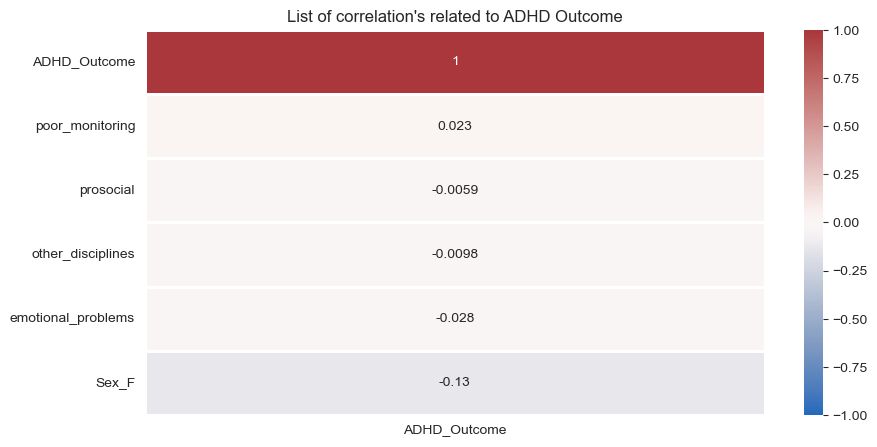

In [28]:
corr_matrix = pd.concat([adhd_qm_df, y], axis=1).corr(method = 'kendall')

fig, ax = plt.subplots(figsize = (10, 5))
sns.set_style("whitegrid")
heat = sns.heatmap(corr_matrix[["ADHD_Outcome"]].sort_values(by='ADHD_Outcome', ascending=False), linewidth=1,annot=True, cmap = 'vlag', vmin=-1)
plt.title("List of correlation's related to ADHD Outcome")
plt.show()

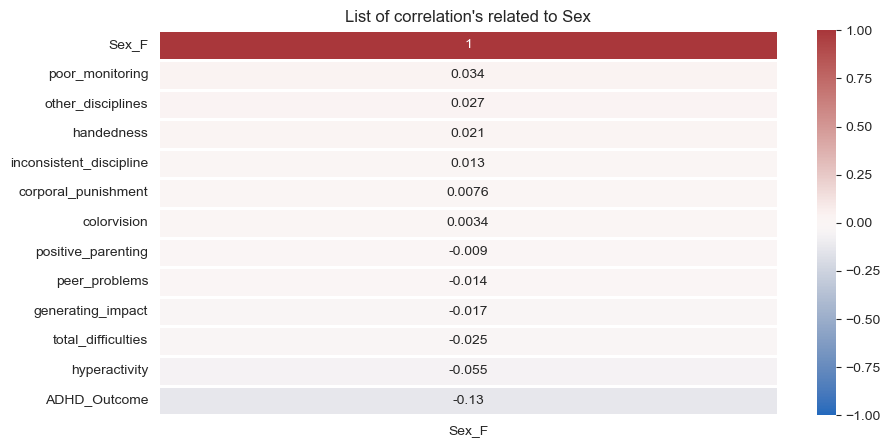

In [29]:
corr_matrix = pd.concat([sex_qm_df, y], axis=1).corr(method = 'kendall')

fig, ax = plt.subplots( figsize = (10, 5))
sns.set_style("whitegrid")
heat = sns.heatmap(corr_matrix[["Sex_F"]].sort_values(by='Sex_F', ascending=False), linewidth=1,annot=True, cmap = 'vlag', vmin=-1)
plt.title("List of correlation's related to Sex")
plt.show()

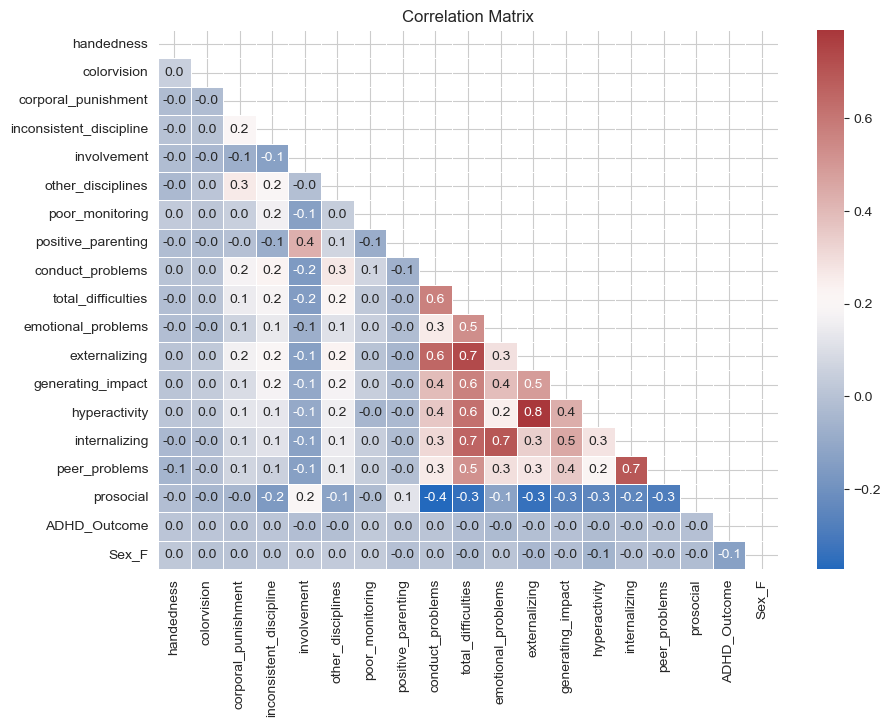

In [30]:
corr_matrix = pd.concat([qm_df, y], axis=1).corr(method = 'kendall')


fig, ax = plt.subplots( figsize = (10, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='vlag', fmt=".1f", linewidths= .5)
plt.title('Correlation Matrix')
plt.show()

#### Conclusion

It's hard to parse these correlations with our target variables. For some reason there is little to no information being teased out here.
So we will rely on our feature selection via mutual info.

### Dendrogram

{1: '#ffff33', 0: '#984ea3'}


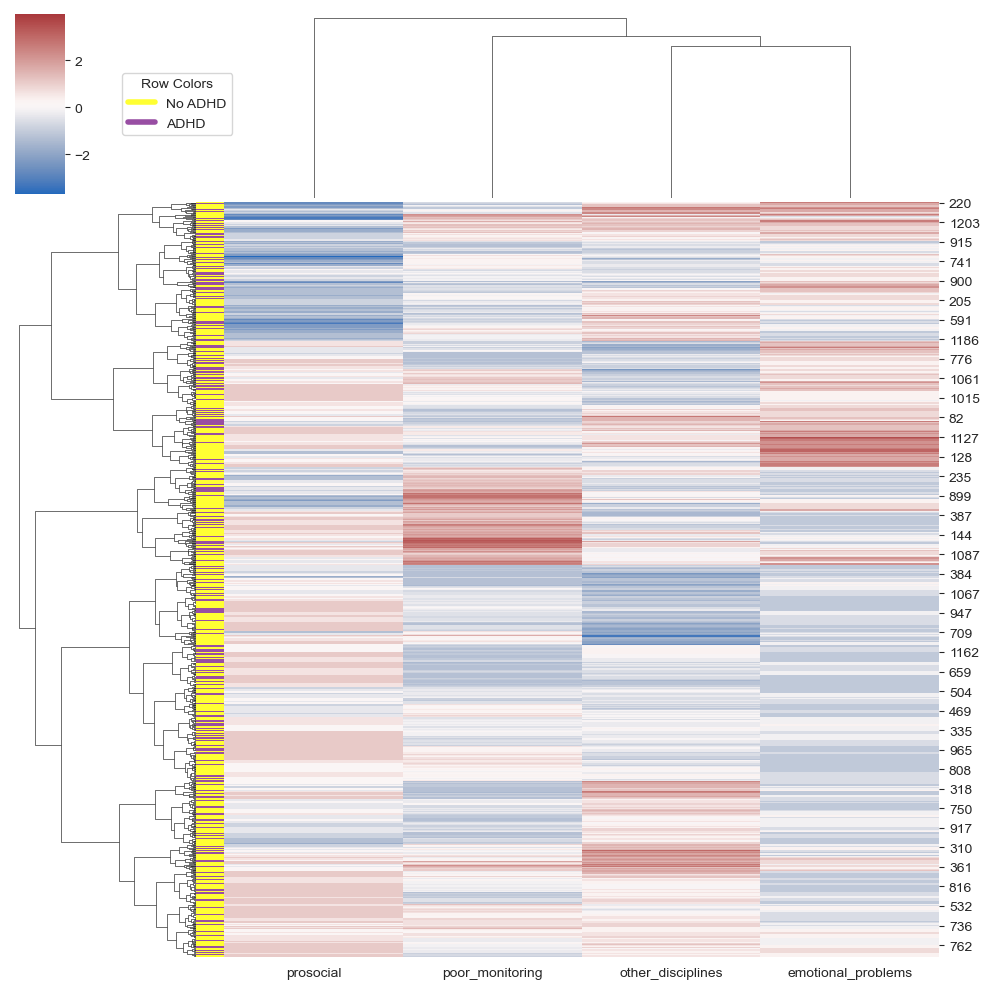

In [31]:
color_array = ["#ffff33","#984ea3"]
# the color for the labels
lut = dict(zip(y["ADHD_Outcome"].unique(), color_array))
print(lut)
row_colors = y["ADHD_Outcome"].map(lut)

sns.clustermap(adhd_qm_df, method="ward", metric="euclidean",row_colors=row_colors.to_numpy(), cmap="vlag")


plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="No ADHD"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="ADHD")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)
)

{1: '#ffff33', 0: '#984ea3'}


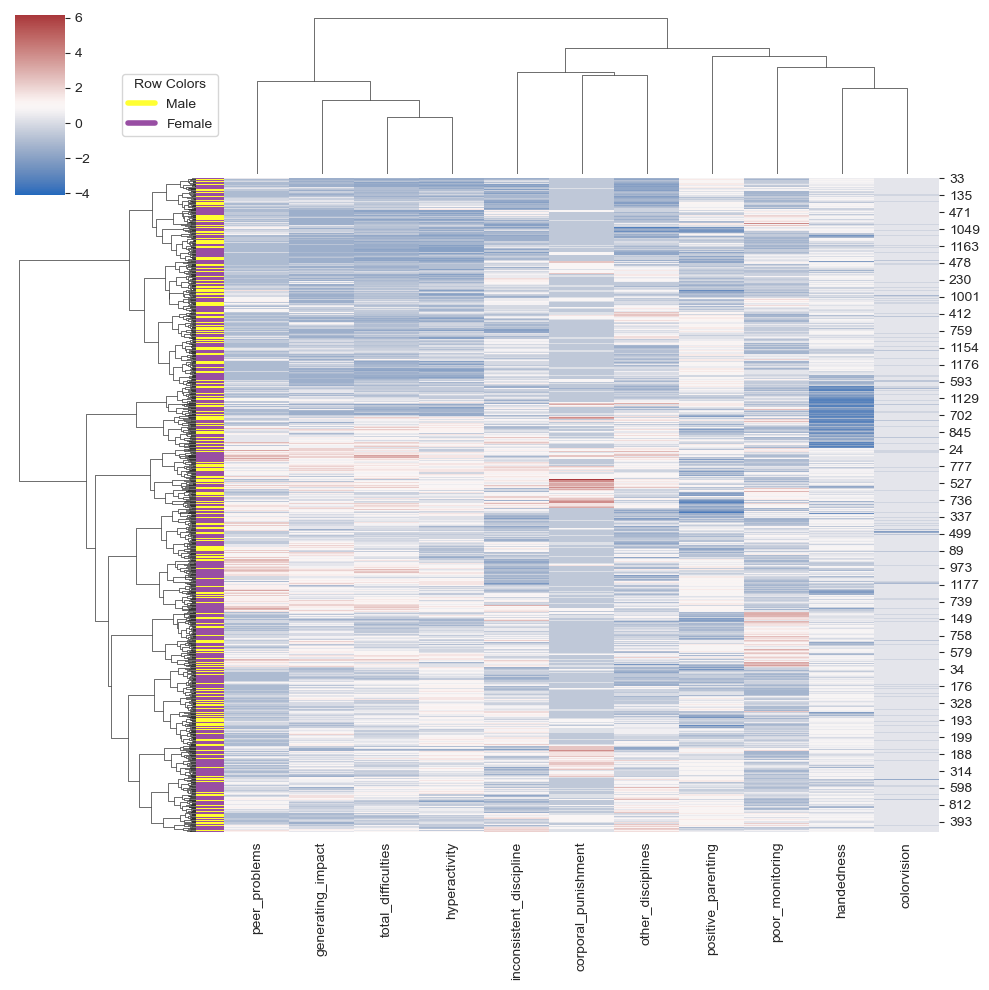

In [32]:
color_array = ["#ffff33","#984ea3"]
# the color for the labels
lut = dict(zip(y["Sex_F"].unique(), color_array))
print(lut)
row_colors = y["Sex_F"].map(lut)

sns.clustermap(sex_qm_df, method="ward", metric="euclidean",row_colors=row_colors.to_numpy(), cmap="vlag")


plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="Male"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="Female")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)  # Position the legend outside the plot
)


#### Conclusion

From above, we can begin to see that we may be able to reduce our features down to possibly 2-3 clusters. Further, it seems easier to parse sex from this data, then it is to parse ADHD.

### Conclusion in Quantative exploration
Moving forward we will be working with the dataframes made above: sex_qm_df and adhd_qm_df

## Categorical

### Initial Feature Drop
For useless feature

In [33]:
if "enroll_year" in cm_df.columns:
    cm_df = cm_df.drop(columns=['enroll_year'])


### Feature selection via mutual info
We will be applying the same method from above.

In [34]:
# FOR ADHD

mi_scores = mutual_info_classif(cm_df, y["ADHD_Outcome"])

mutual_info_dict = dict(zip(cm_df.columns, mi_scores))

adhd_cm_selected_features = [feature for feature, score in mutual_info_dict.items() if score > 0]

adhd_cm_df = cm_df[adhd_cm_selected_features]

print(adhd_cm_df.shape)
print(adhd_cm_df.head())

(1120, 38)
   study_site_Harlem  study_site_MRV  study_site_Midtown  \
0               True           False               False   
1              False           False               False   
2              False           False               False   
3              False           False               False   
4              False           False               False   

   ethnicity_Not Hispanic or Latino  race_Asian  race_Black/African American  \
0                             False       False                        False   
1                              True       False                        False   
2                             False       False                        False   
3                             False       False                        False   
4                              True       False                         True   

   race_Hispanic  race_Indian  race_Two or more races  race_White/Caucasian  \
0          False        False                   False               

In [35]:
# FOR SEX

mi_scores = mutual_info_classif(cm_df, y["Sex_F"])

mutual_info_dict = dict(zip(cm_df.columns, mi_scores))

selected_features = [feature for feature, score in mutual_info_dict.items() if score > 0]

sex_cm_df = cm_df[selected_features]

print(sex_cm_df.shape)
print(sex_cm_df.head())

(1120, 27)
   study_site_Midtown  study_site_Staten Island  \
0               False                     False   
1               False                      True   
2               False                      True   
3               False                      True   
4               False                      True   

   ethnicity_Not Hispanic or Latino  race_Black/African American  \
0                             False                        False   
1                              True                        False   
2                             False                        False   
3                             False                        False   
4                              True                         True   

   race_Choose not to specify  race_Hispanic  race_Two or more races  \
0                       False          False                   False   
1                       False          False                   False   
2                       False           True             

### Correlation

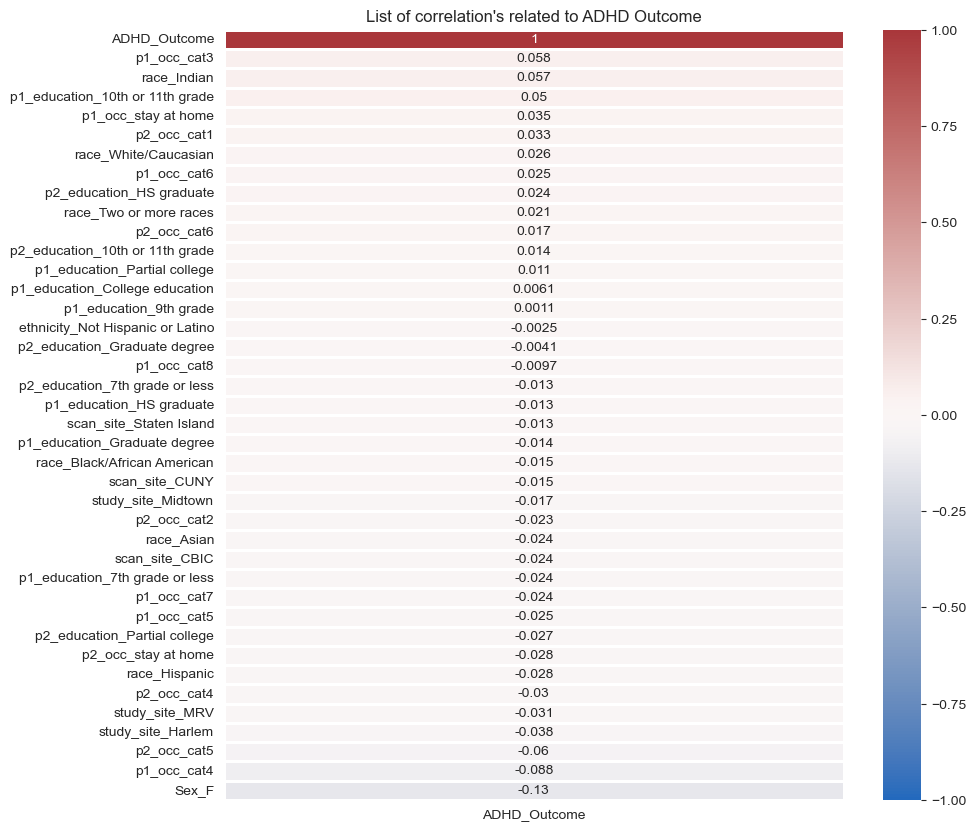

In [36]:
corr_matrix = pd.concat([adhd_cm_df, y], axis=1).corr()

fig, ax = plt.subplots(figsize = (10, 10))
sns.set_style("whitegrid")
heat = sns.heatmap(corr_matrix[["ADHD_Outcome"]].sort_values(by='ADHD_Outcome', ascending=False), linewidth=1,annot=True, cmap = 'vlag', vmin=-1)
plt.title("List of correlation's related to ADHD Outcome")
plt.show()

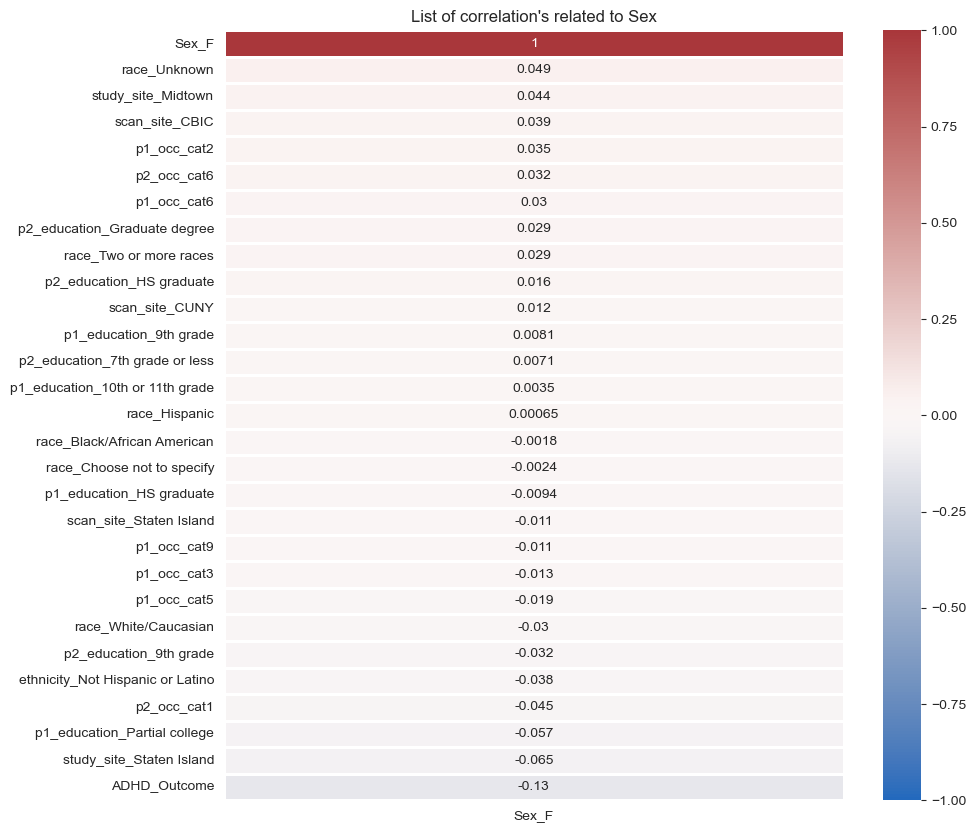

In [37]:
corr_matrix = pd.concat([sex_cm_df, y], axis=1).corr()

fig, ax = plt.subplots( figsize = (10, 10))
sns.set_style("whitegrid")
heat = sns.heatmap(corr_matrix[["Sex_F"]].sort_values(by='Sex_F', ascending=False), linewidth=1,annot=True, cmap = 'vlag', vmin=-1)
plt.title("List of correlation's related to Sex")
plt.show()

#### Conclusion
Again, its a little hard to tease out information from these graphs.

### Dendrograms

{1: '#ffff33', 0: '#984ea3'}


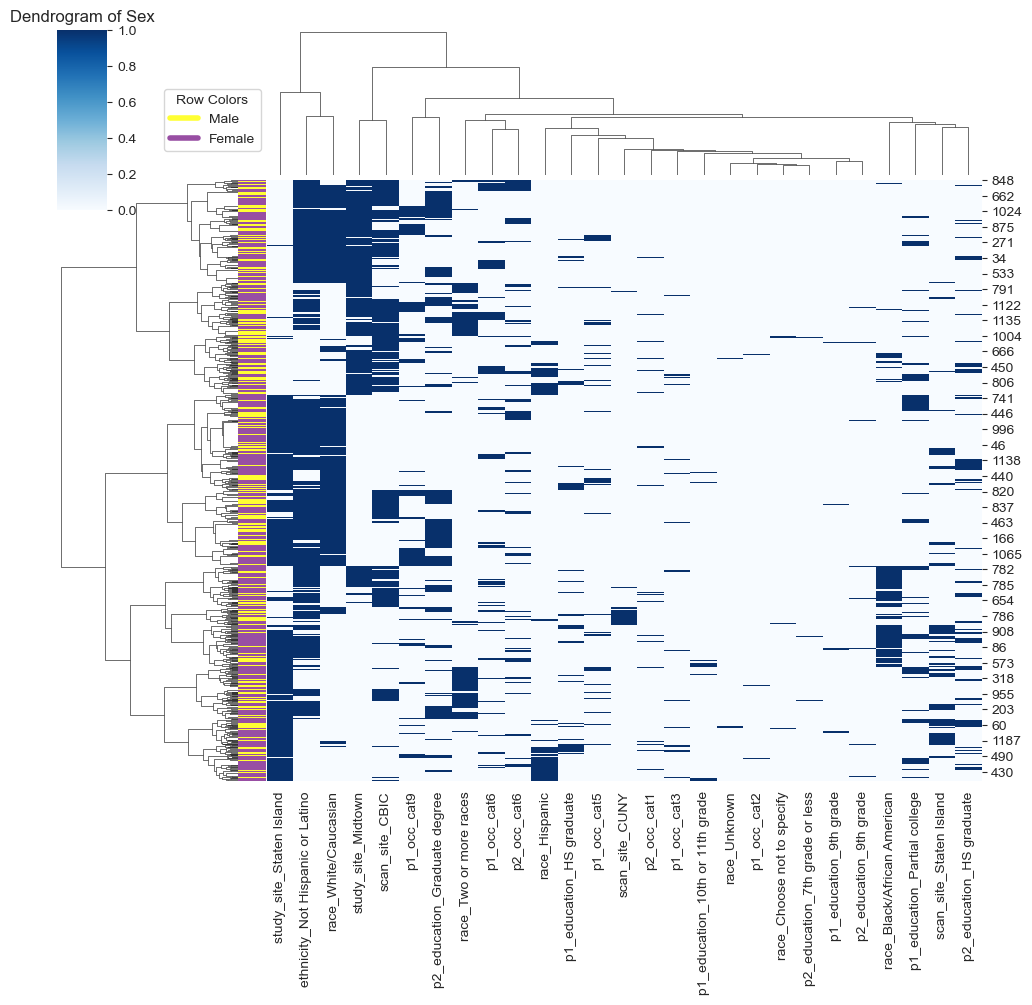

In [38]:
color_array = ["#ffff33","#984ea3"]
#"#984ea3","#a65628",
# the color for the labels
lut = dict(zip(y["Sex_F"].unique(), color_array))
print(lut)
row_colors = y["Sex_F"].map(lut)

sns.clustermap(
    sex_cm_df,
    method="ward",
    metric="euclidean",
    cmap="Blues",
    row_colors=row_colors.to_numpy(),
)


plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="Male"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="Female")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)  # Position the legend outside the plot
)

plt.title("Dendrogram of Sex")
plt.show()

{1: '#ffff33', 0: '#984ea3'}


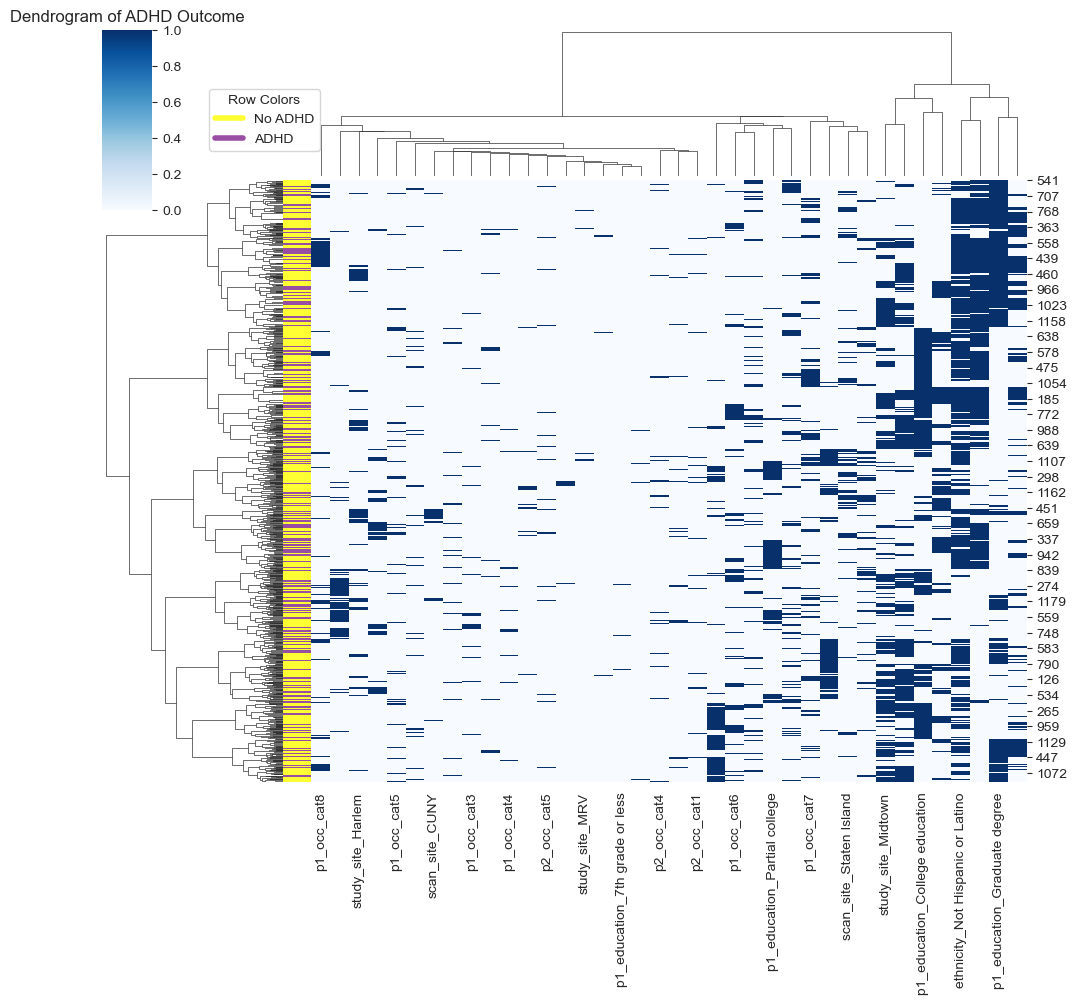

In [39]:
color_array = ["#ffff33","#984ea3"]
#"#984ea3","#a65628",
# the color for the labels
lut = dict(zip(y["ADHD_Outcome"].unique(), color_array))
print(lut)
row_colors = y["ADHD_Outcome"].map(lut)

sns.clustermap(
    adhd_cm_df,
    method="ward",
    metric="euclidean",
    cmap="Blues",
    row_colors=row_colors.to_numpy(),
)


plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="No ADHD"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="ADHD")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)  # Position the legend outside the plot
)

plt.title("Dendrogram of ADHD Outcome")
plt.show()

#### Conclusion
We can somewhat see tiny clusters arising from the row colors (yellow/purple) of both our histograms.

## FMRI

### Single connectome example

<Axes: >

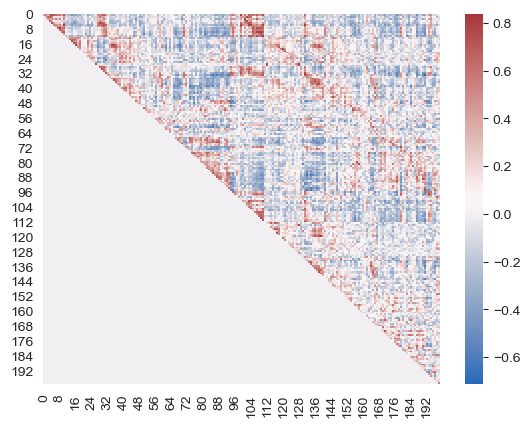

In [40]:
sns.heatmap(fcm_3d_df[867], cmap="vlag")

### Dendrogram of a single connectome.

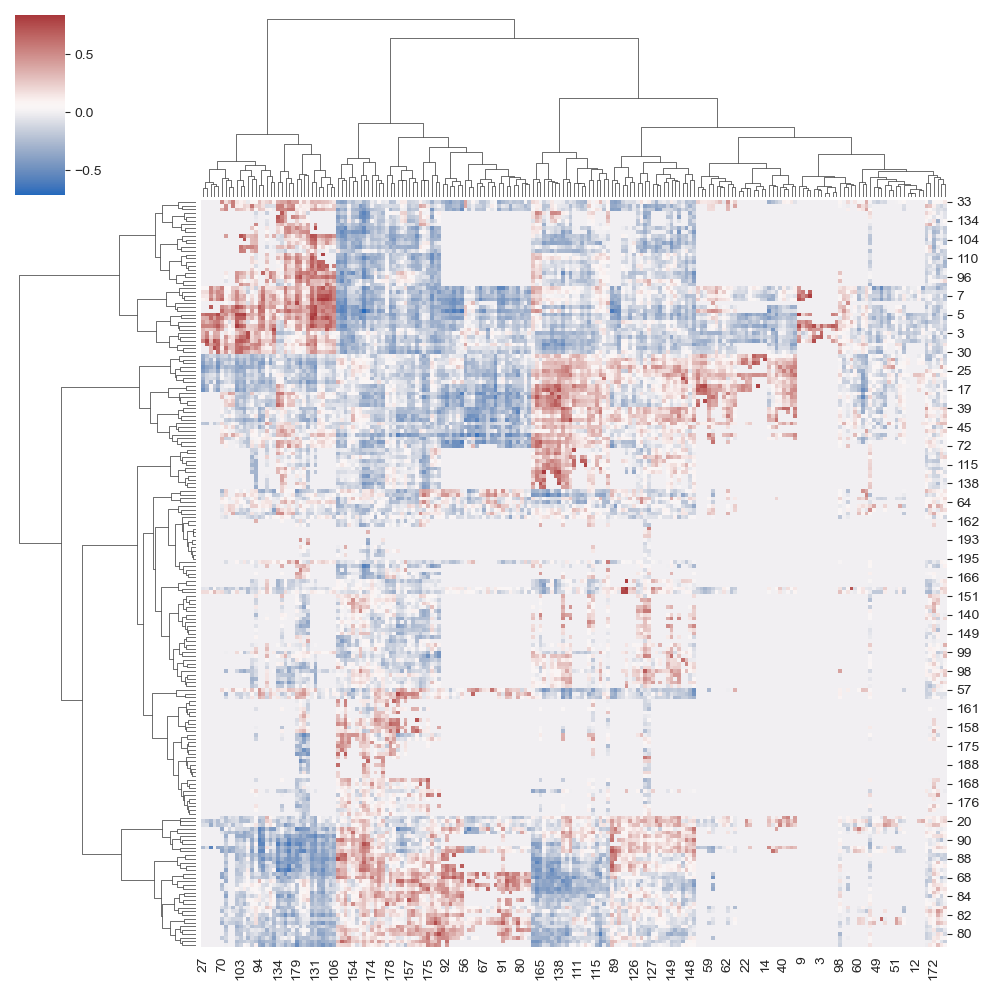

In [41]:
sns.clustermap(fcm_3d_df[867], method="ward", metric="euclidean", cmap="vlag")

It may be viable to cluster this data via for around 10x15 clusters. The following process details this.

## Using Histogram deltas

Here we analyze the fMRI connectome edges and extract the 1000 edges with the largest effect size for each sex and ADHD outcome variables.

In [42]:
combined_df = pd.concat([fcm_df, y], axis=1)

In [43]:
## Sex section

# Split dataframe by sex
sex_f = combined_df[combined_df['Sex_F'] == 1]
sex_m = combined_df[combined_df['Sex_F'] == 0]

# Calculate means for each feature
f_means = sex_f.mean()
m_means = sex_m.mean()

# Calculate difference between means and sort
sex_delta = pd.Series(abs(f_means - m_means))
sex_sorted = sex_delta.sort_values(ascending=False)
sex_hist = sex_sorted.drop(['Sex_F', 'ADHD_Outcome'])

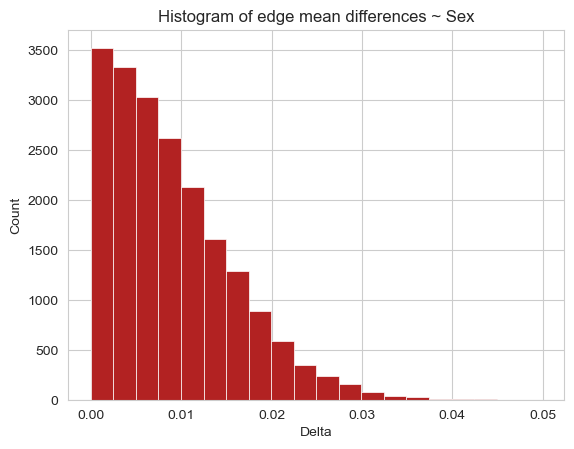

In [44]:
# Plot histogram of effect sizes
plt.hist(sex_hist, density=False, bins=20, linewidth =.5, edgecolor='white', color='firebrick')
plt.ylabel('Count')
plt.xlabel('Delta')
plt.title('Histogram of edge mean differences ~ Sex')
plt.show()

Here we can see a visualzation of how many edges have weak strength/deltas.

In [45]:
# Retrieve index values for 1000 strongest edges 
sex_delta = sex_delta.drop('ADHD_Outcome')
sex_top_n = sex_delta.nlargest(n=1000, keep='all')
sex_n_edges = list(sex_top_n.index)

# Slice dataframe by strongest 1000 edges
topn_edges_sex = combined_df.loc[:, sex_n_edges]

In [46]:
# Here we perform a t-test on each selected variable and plot the results to evaluate significance

# Split dataframe by sex
sex_f = pd.DataFrame(topn_edges_sex[topn_edges_sex['Sex_F'] == 1])
sex_m = pd.DataFrame(topn_edges_sex[topn_edges_sex['Sex_F'] == 0])

t_tst_pvals = []

# Compare stats for each feature
for i in range(1, len(sex_f.columns)):
    result = stats.ttest_ind(a = sex_f.iloc[:,i], b = sex_m.iloc[:,i], equal_var=True)
    t_tst_pvals.append(result.pvalue)


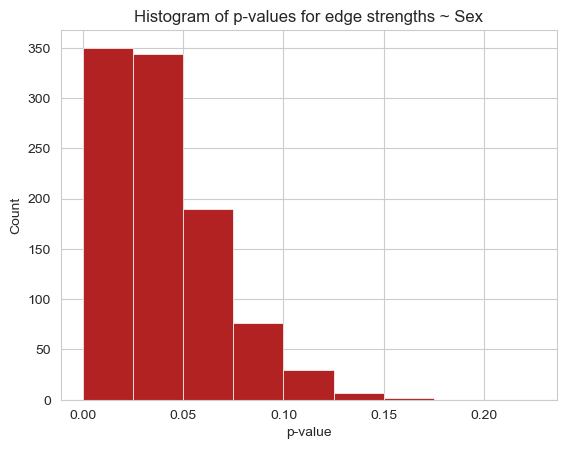

In [47]:
# Plot histogram
fig, ax = plt.subplots(1, 1)
bins = np.arange(0,0.25,0.025)

ax.hist(t_tst_pvals, bins, linewidth =.5, edgecolor='white', color='firebrick')

ax.set_title('Histogram of p-values for edge strengths ~ Sex')
ax.set_xlabel('p-value')
ax.set_ylabel('Count')
plt.show()

Our selection of variables with the highest effect size also have low p-values, majority being under 0.10.

In [48]:
## ADHD Section

# Split dataframe by ADHD status
adhd_pos = combined_df[combined_df['ADHD_Outcome'] == 1]
adhd_neg = combined_df[combined_df['ADHD_Outcome'] == 0]

# Calculate means for each feature
pos_means = adhd_pos.mean()
neg_means = adhd_neg.mean()

# Calculate difference between means and sort
adhd_delta = abs(pos_means - neg_means)
adhd_sorted = adhd_delta.sort_values(ascending=False)
adhd_hist = adhd_sorted.drop(['Sex_F', 'ADHD_Outcome'])

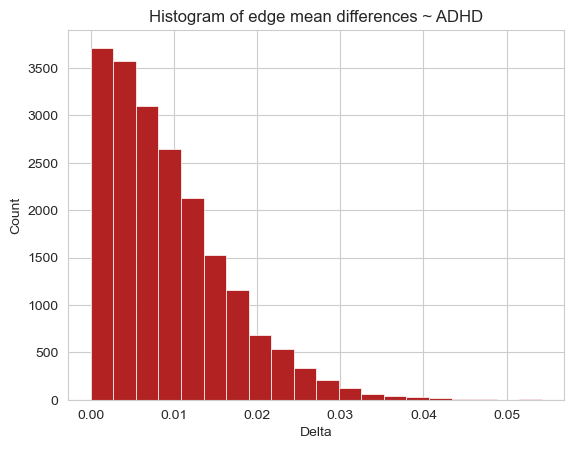

In [49]:
# Plot histogram of deltas
plt.hist(adhd_hist, density=False, bins=20, linewidth =.5, edgecolor='white', color='firebrick')
plt.ylabel('Count')
plt.xlabel('Delta')
plt.title('Histogram of edge mean differences ~ ADHD')
plt.show()

Here we can see a visualzation of how many edges have weak strength/deltas.

In [50]:
# Retrieve index values for 1000 strongest edges 
adhd_delta = adhd_delta.drop('Sex_F')
adhd_top_n = adhd_delta.nlargest(n=1000, keep='all')
adhd_n_edges = list(adhd_top_n.index)

# Slice dataframe by strongest 1000 edges
topn_edges_adhd = combined_df.loc[:, adhd_n_edges]

In [51]:
# Here we perform a t-test on each selected variable and plot the results to evaluate significance

# Split dataframe by ADHD status
adhd_pos = pd.DataFrame(topn_edges_adhd[topn_edges_adhd['ADHD_Outcome'] == 1])
adhd_neg = pd.DataFrame(topn_edges_adhd[topn_edges_adhd['ADHD_Outcome'] == 0])

# Compare stats for each feature
t_tst_pvals_A = []
for i in range(1, len(adhd_pos.columns)):
    result_A = stats.ttest_ind(a = adhd_pos.iloc[:,i], b = adhd_neg.iloc[:,i], equal_var=True)
    t_tst_pvals_A.append(result_A.pvalue)

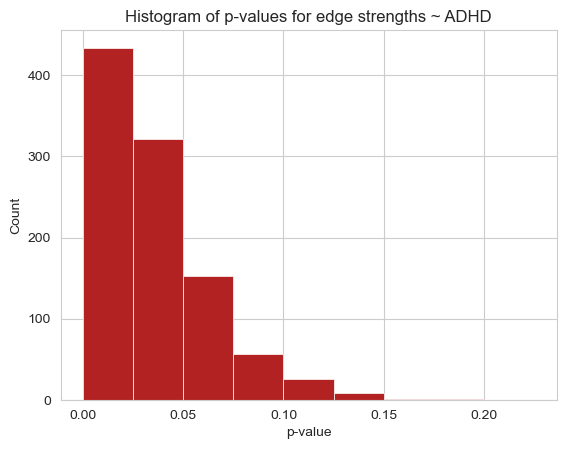

In [52]:
# Plot histogram
fig, ax = plt.subplots(1, 1)
bins = np.arange(0,0.25,0.025)
ax.hist(t_tst_pvals_A, bins, linewidth =.5, edgecolor='white', color='firebrick')

ax.set_title('Histogram of p-values for edge strengths ~ ADHD')
ax.set_xlabel('p-value')
ax.set_ylabel('Count')
plt.show()


Again, our selection of variables with the highest effect size also have low p-values, majority being under 0.10.

In [80]:
# Union of strongest edges for both factors
sex_edges = sex_top_n.drop('Sex_F')
sex_edges = list(sex_edges.index)
adhd_edges = adhd_top_n.drop('ADHD_Outcome')
adhd_edges = list(adhd_edges.index)

# Combine unique edge indices
all_edges = list(set(sex_edges) | set(adhd_edges))
topn_edges_adhd = fcm_df.loc[:, adhd_edges]
topn_edges_sex = fcm_df.loc[:, sex_edges]
print(len(all_edges))

1944


In [81]:
# Slice by top edges for both factors
topn_edges_all = combined_df.loc[:, all_edges]
print(topn_edges_all.shape)
print(topn_edges_all.head(5))

(1120, 1944)
   56throw_189thcolumn  94throw_162thcolumn  65throw_93thcolumn  \
0            -0.207578             0.195476            0.148633   
1            -0.074085            -0.040138            0.030704   
2             0.198040             0.053245           -0.243647   
3            -0.449250            -0.091853           -0.339413   
4            -0.073168            -0.379599           -0.200454   

   27throw_98thcolumn  2throw_77thcolumn  158throw_197thcolumn  \
0            0.223436          -0.082917             -0.146149   
1            0.444415          -0.315296              0.272476   
2            0.334250          -0.193397              0.265745   
3            0.024423          -0.261765              0.051712   
4           -0.146807          -0.038585             -0.033938   

   14throw_112thcolumn  2throw_126thcolumn  15throw_44thcolumn  \
0             0.236635            0.346653            0.160401   
1             0.000738           -0.162310           -0



The training dataframe is now subsetted for the 1000 most discriminatory fMRI edges for both patient sex and ADHD outcome. Edge overlap was 4.9% resulting in a final variable count of 1944. This will serve as the primary dataframe for model training and testing.

### Clustering Histogram Deltas

In [101]:

#row_indices, col_indices = get_n_col_row(fcm_df.columns)

n_regions_row = max(row_indices) + 1
n_regions_col = max(col_indices)

connectomes_matrices = []
#now given that we know how big each connectome should be, for each participant we will reconstruct the row of data into a 2-D matrix
for i in range(topn_edges_adhd.shape[0]):
    connectome_data = topn_edges_adhd.iloc[i]

    connectome_matrix = np.zeros((n_regions_row, n_regions_col))

    for col in topn_edges_adhd.columns:
        parts = col.split("throw_")
        row_index = int(parts[0])
        col_index = int(parts[1].replace("thcolumn", ""))
        connectome_matrix[row_index, col_index - 1] = connectome_data[col]

    connectomes_matrices.append(connectome_matrix)

_3d_df = np.array(connectomes_matrices)
print("New FMRI dataframe:", _3d_df.shape)
#40s runtime

New FMRI dataframe: (1120, 199, 199)


#### Visualizing our extracted edges

<Axes: >

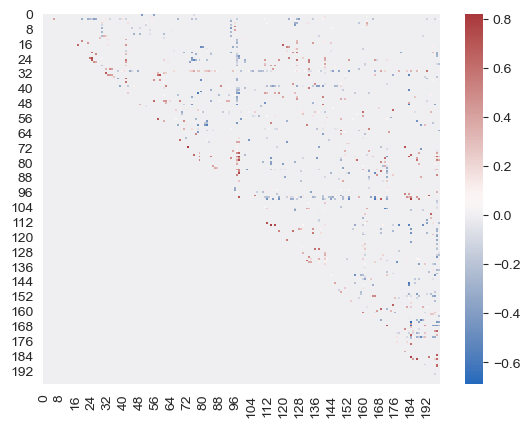

In [84]:
sns.heatmap(_3d_df[700], cmap="vlag")

In [67]:
#Hierarchical clustering of a single connectome
linkage_matrix = linkage(_3d_df[0], method='ward', metric='euclidean')
clusters = fcluster(linkage_matrix, 2, criterion='distance')
print("Clusters found:", clusters)

Clusters found: [3 3 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 1 3 3 3 3 3
 1 3 1 1 1 3 3 1 1 1 1 3 3 1 3 1 3 3 3 3 1 3 3 2 1 1 3 3 3 3 3 3 3 2 3 2 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 1 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2
 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


In [73]:
def within_cluster_connectivity(matrix, cluster_labels):
    cluster_ids = np.unique(cluster_labels)
    features = []
    for cluster in cluster_ids: #for each cluster, find the mean of its edges
        mask = cluster_labels == cluster
        sub_matrix = matrix[mask][:, mask]
        mean_connectivity = np.mean(sub_matrix)
        features.append(mean_connectivity)
    return features

# example
print(within_cluster_connectivity(_3d_df[0], clusters))

[0.018916131311785028, 0.02397639002560705, 0.0010106743168918303, 0.0]


In [72]:
def between_cluster_connectivity(matrix, cluster_labels): #find connectivity between all clusters
    cluster_ids = np.unique(cluster_labels)
    features = []
    for i, cluster_i in enumerate(cluster_ids): #cluster 1
        for j, cluster_j in enumerate(cluster_ids): #cluster2
            if i >= j:
                continue
            mask_i = cluster_labels == cluster_i #select only relevant cluster
            mask_j = cluster_labels == cluster_j #select only relevant cluster
            sub_matrix = matrix[mask_i][:, mask_j] #define roi
            mean_connectivity = np.mean(sub_matrix)
            features.append(mean_connectivity)
    return features

# example
print(between_cluster_connectivity(_3d_df[0], clusters))

[0.02261808103427412, 0.0016564455117672621, -0.014639698256059964, 0.005954559782433362, 0.0, 0.0012723645411331875]


### Generating ADHD Cluster Features

In [102]:
all_features = []

#apply both functions above to each all rows in our fcm_3d_df
for i in range(_3d_df.shape[0]):
    #for each matrix, get a hierarchical cluster mapping
    connectome = _3d_df[i]
    linkage_matrix = linkage(connectome, method='ward', metric='euclidean')
    clusters = fcluster(linkage_matrix, 2, criterion='maxclust')

    #compute cluster features
    within_features = within_cluster_connectivity(connectome, clusters)
    between_features = between_cluster_connectivity(connectome, clusters)

    #for all clusters append corresponding feature computation and add to features for the row
    features = {f'Within_Cluster_{i+1}_Connectivity':
                           within_features[i] if i < len(within_features) else None
                           for i in range(2)
    }
    features.update({f'Between_Cluster_{i+1}_Connectivity':
                                between_features[i] if i < len(between_features) else None
                                for i in range(len(between_features))})
    #add to master featurelist
    all_features.append(features)

fcm_adhd_cluster_features = pd.DataFrame(all_features, index=topn_edges_adhd.index)

print(fcm_adhd_cluster_features.head())
print(fcm_adhd_cluster_features.shape)

   Within_Cluster_1_Connectivity  Within_Cluster_2_Connectivity  \
0                       0.018916                       0.001195   
1                       0.010828                       0.001205   
2                       0.001592                       0.000000   
3                       0.029444                       0.000806   
4                       0.000711                       0.000000   

   Between_Cluster_1_Connectivity  
0                        0.002258  
1                        0.005600  
2                        0.000243  
3                        0.000359  
4                        0.000000  
(1120, 3)


### Generating Sex Cluster Features

In [103]:
n_regions_row = max(row_indices) + 1
n_regions_col = max(col_indices)

connectomes_matrices = []
for i in range(topn_edges_sex.shape[0]):
    connectome_data = topn_edges_sex.iloc[i]

    connectome_matrix = np.zeros((n_regions_row, n_regions_col))

    for col in topn_edges_sex.columns:
        parts = col.split("throw_")
        row_index = int(parts[0])
        col_index = int(parts[1].replace("thcolumn", ""))
        connectome_matrix[row_index, col_index - 1] = connectome_data[col]

    connectomes_matrices.append(connectome_matrix)

_3d_df = np.array(connectomes_matrices)

all_features = []

for i in range(_3d_df.shape[0]):
    connectome = _3d_df[i]
    linkage_matrix = linkage(connectome, method='ward', metric='euclidean')
    clusters = fcluster(linkage_matrix, 2, criterion='maxclust')

    within_features = within_cluster_connectivity(connectome, clusters)
    between_features = between_cluster_connectivity(connectome, clusters)

    features = {f'Within_Cluster_{i+1}_Connectivity':
                           within_features[i] if i < len(within_features) else None
                           for i in range(2)
    }
    features.update({f'Between_Cluster_{i+1}_Connectivity':
                                between_features[i] if i < len(between_features) else None
                                for i in range(len(between_features))})
    all_features.append(features)

fcm_sex_cluster_features = pd.DataFrame(all_features, index=topn_edges_sex.index)

print(fcm_sex_cluster_features.head())
print(fcm_sex_cluster_features.shape)

   Within_Cluster_1_Connectivity  Within_Cluster_2_Connectivity  \
0                       0.000000                       0.001551   
1                       0.017526                       0.001701   
2                       0.000000                       0.001458   
3                       0.000000                       0.000602   
4                       0.136669                       0.000846   

   Between_Cluster_1_Connectivity  
0                       -0.007900  
1                        0.005385  
2                        0.015344  
3                        0.000881  
4                        0.011837  
(1120, 3)


## PCA Decomposition

In [97]:
# PCA Decomposition
connect_pca = PCA(n_components=1000)
X_PCA = connect_pca.fit_transform(fcm_df)

# Cast to dataframe
X_PCA = pd.DataFrame(X_PCA)

The number of components selected for PCA is determined by analyzing the explained variance ratios:

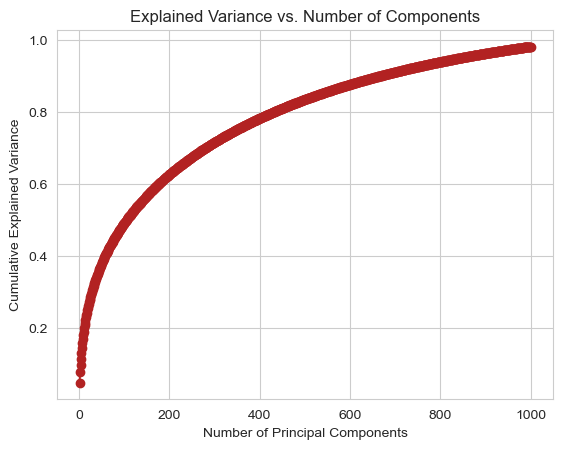

In [98]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(connect_pca.explained_variance_ratio_)

# Plot the explained variance
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='firebrick')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

In [ ]:
# FOR ADHD

mi_scores = mutual_info_classif(qm_df, y["ADHD_Outcome"])

mutual_info_dict = dict(zip(qm_df.columns, mi_scores))

adhd_qm_selected_features = [feature for feature, score in mutual_info_dict.items() if score > 0]

adhd_qm_df = qm_df[adhd_qm_selected_features]

print(adhd_qm_df.shape)
print(adhd_qm_df.head())

# Analysis methodology

In our above analysis, we've used the following methods:
- Mutual information
- Correlation
- Dendrograms
- Hierarchical clustering
- Network analylzing
- Histogram differences
- T-tests


# Results

## Model testing



In [77]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cross_decomposition import PLSRegression

# Set seed
random.seed(10)

### Building a pipeline to help us estimate good models.

In [104]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(),
        'params': {
            'model__C': [0.001, 0.01, 0.1, 1, 5, 10, 15, 20],

            'model__penalty': ['l1', 'l2', 'elasticnet'],

            'model__multi_class': ['auto', 'ovr', 'multinomial']
        }
    },


    'SVM': {
        'model': SVC(),
        'params': {
            'model__C': [0.01, 0.1, 1, 3, 5, 10, 20],

            'model__gamma': ['scale', 'auto'],

            'model__kernel': ['rbf', 'linear', 'poly'],

        }
    },

}


def optimize_models(data_dict, model_list, y_data):
    all_results = []
    test_results = []

    for dataset_name, dataset in data_dict.items():
        print(f"Processing {dataset_name}...")



        X_train, X_test, y_train, y_test = train_test_split(dataset, y_data, test_size=0.3, shuffle=True)


        dataset_results = []
        best_models = {}

        for model_name, config in model_list.items():
            print(f"Training {model_name}...")
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('model', config['model'])
            ])

            grid = GridSearchCV(pipeline, config['params'], cv=4, scoring='accuracy', n_jobs=-1)
            grid.fit(X_train, y_train)

            best_models[model_name] = grid.best_estimator_
            dataset_results.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'Best Params': grid.best_params_,
                'CV Accuracy': grid.best_score_
            })

        for model_name, model in best_models.items():
            y_pred = model.predict(X_test)
            test_accuracy = accuracy_score(y_test, y_pred)
            test_results.append({
                'Test Accuracy': test_accuracy
            })

        all_results.extend(dataset_results)

    cv_results_df = pd.DataFrame(all_results)
    test_results_df = pd.DataFrame(test_results)

    return  pd.concat([cv_results_df, test_results_df], axis=1)


### Quantative and Categorical

#### Predicting ADHD

In [140]:
cm_qm_adhd_df = pd.concat([adhd_qm_df, adhd_cm_df], axis=1)
qm_cm_adhd_dictionary = {
                            "cm_qm_adhd_df": cm_qm_adhd_df
}

qm_cm_results_adhd = optimize_models(qm_cm_adhd_dictionary, models, y['ADHD_Outcome'])

Processing cm_qm_adhd_df...
Training Logistic Regression...
Training SVM...


In [141]:
qm_cm_results_adhd

,Dataset,Model,Best Params,CV Accuracy,Test Accuracy
0,cm_qm_adhd_df,Logistic Regression,"{'model__C': 0.001, 'model__multi_class': 'aut...",0.681122,0.702381
1,cm_qm_adhd_df,SVM,"{'model__C': 0.01, 'model__gamma': 'scale', 'm...",0.681122,0.702381


#### Predicting Sex

In [142]:
cm_qm_sex_df = pd.concat([sex_qm_df, sex_cm_df], axis=1)
qm_cm_sex_dictionary = {
                            "cm_qm_sex_df": cm_qm_sex_df
}

qm_cm_results_sex = optimize_models(qm_cm_sex_dictionary, models, y['Sex_F'])

Processing cm_qm_sex_df...
Training Logistic Regression...
Training SVM...


In [143]:
qm_cm_results_sex

,Dataset,Model,Best Params,CV Accuracy,Test Accuracy
0,cm_qm_sex_df,Logistic Regression,"{'model__C': 0.001, 'model__multi_class': 'aut...",0.645408,0.663690
1,cm_qm_sex_df,SVM,"{'model__C': 0.01, 'model__gamma': 'scale', 'm...",0.650510,0.657738


#### Conclusion

Here we can see it's hard to predict with just our quantative and categorical dataframes combined.

### Just FMRI

#### Predicting ADHD Outcome

In [105]:
#We will range over all of our datasets and see our best performing ones.
fmri_dataset_dictionary = {
                        "top_edges_adhd": topn_edges_adhd,
                        "top_edges_all": topn_edges_all,
                        "fmri_pca": X_PCA,
                        "fmri_network_strength": fcm_cluster_strength_df,
                        "fmri_cluster_features": fcm_adhd_cluster_features,
}

fmri_results_adhd = optimize_models(fmri_dataset_dictionary, models, y['ADHD_Outcome'])

Processing top_edges_adhd...
Training Logistic Regression...
Training SVM...
Processing top_edges_all...
Training Logistic Regression...
Training SVM...
Processing fmri_pca...
Training Logistic Regression...
Training SVM...
Processing fmri_network_strength...
Training Logistic Regression...
Training SVM...
Processing fmri_cluster_features...
Training Logistic Regression...
Training SVM...


In [109]:
fmri_results_adhd

,Dataset,Model,Best Params,CV Accuracy,Test Accuracy
0,top_edges_adhd,Logistic Regression,"{'model__C': 0.001, 'model__multi_class': 'aut...",0.728316,0.770833
1,top_edges_adhd,SVM,"{'model__C': 3, 'model__gamma': 'scale', 'mode...",0.729592,0.764881
2,top_edges_all,Logistic Regression,"{'model__C': 0.01, 'model__multi_class': 'auto...",0.732143,0.735119
3,top_edges_all,SVM,"{'model__C': 3, 'model__gamma': 'scale', 'mode...",0.719388,0.714286
4,fmri_pca,Logistic Regression,"{'model__C': 0.001, 'model__multi_class': 'aut...",0.677296,0.711310
5,fmri_pca,SVM,"{'model__C': 0.01, 'model__gamma': 'scale', 'm...",0.677296,0.711310
6,fmri_network_strength,Logistic Regression,"{'model__C': 0.001, 'model__multi_class': 'mul...",0.692602,0.684524
7,fmri_network_strength,SVM,"{'model__C': 3, 'model__gamma': 'scale', 'mode...",0.691327,0.693452
8,fmri_cluster_features,Logistic Regression,"{'model__C': 0.001, 'model__multi_class': 'aut...",0.684949,0.693452
9,fmri_cluster_features,SVM,"{'model__C': 0.01, 'model__gamma': 'scale', 'm...",0.684949,0.693452


Using only top edges (combined sex and ADHD) we get a .73 accuracy and test score for logistic logression.

#### Predicting Sex Outcome

In [107]:
fmri_dataset_dictionary = {
                        "top_edges_sex": topn_edges_sex,
                        "top_edges_all": topn_edges_all,
                        "fmri_pca": X_PCA,
                        "fmri_network_strength": fcm_cluster_strength_df,
                        "fmri_cluster_features": fcm_sex_cluster_features,
}

fmri_results_sex = optimize_models(fmri_dataset_dictionary, models, y['Sex_F'])



Processing top_edges_sex...
Training Logistic Regression...
Training SVM...
Processing top_edges_all...
Training Logistic Regression...
Training SVM...
Processing fmri_pca...
Training Logistic Regression...
Training SVM...
Processing fmri_network_strength...
Training Logistic Regression...
Training SVM...
Processing fmri_cluster_features...
Training Logistic Regression...
Training SVM...


In [108]:
fmri_results_sex

,Dataset,Model,Best Params,CV Accuracy,Test Accuracy
0,top_edges_sex,Logistic Regression,"{'model__C': 0.001, 'model__multi_class': 'aut...",0.701531,0.726190
1,top_edges_sex,SVM,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.681122,0.705357
2,top_edges_all,Logistic Regression,"{'model__C': 0.001, 'model__multi_class': 'aut...",0.692602,0.732143
3,top_edges_all,SVM,"{'model__C': 3, 'model__gamma': 'scale', 'mode...",0.695153,0.726190
4,fmri_pca,Logistic Regression,"{'model__C': 0.001, 'model__multi_class': 'aut...",0.653061,0.645833
5,fmri_pca,SVM,"{'model__C': 0.01, 'model__gamma': 'scale', 'm...",0.653061,0.645833
6,fmri_network_strength,Logistic Regression,"{'model__C': 0.001, 'model__multi_class': 'aut...",0.660714,0.627976
7,fmri_network_strength,SVM,"{'model__C': 5, 'model__gamma': 'scale', 'mode...",0.663265,0.625000
8,fmri_cluster_features,Logistic Regression,"{'model__C': 0.01, 'model__multi_class': 'mult...",0.640306,0.681548
9,fmri_cluster_features,SVM,"{'model__C': 0.01, 'model__gamma': 'scale', 'm...",0.637755,0.681548


Using top sex edges, we get a 70% accuracy and 72% test score with logistic regression.

#### Conclusion

Considering all of our different exploration techniques of FMRI

### FMRI + Categroical + Quantative modelling

Given good performance on logistic regression, we will search more possible parameters, and exclude SVM.

In [115]:
final_models = {
'Logistic Regression': {
    'model': LogisticRegression(),
    'params': {
        'model__C': [0.001, 0.01, 0.1, 1],
        'model__penalty': ['l1','l2'],
        'model__solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg', 'sag'],
        'model__tol': [1e-4, 1e-3, 1e-2],
        'model__class_weight': [None, 'balanced'],
        'model__fit_intercept': [True, False],
    }
    },
}


In [116]:
all_adhd_df = pd.concat([adhd_qm_df, adhd_cm_df, topn_edges_adhd, fcm_adhd_cluster_features], axis=1)
all_adhd_dictionary = {
                            "all_adhd_df": all_adhd_df
}

all_results_adhd = optimize_models(all_adhd_dictionary, final_models, y["ADHD_Outcome"])


Processing all_adhd_df...
Training Logistic Regression...


In [117]:
all_results_adhd

,Dataset,Model,Best Params,CV Accuracy,Test Accuracy
0,all_adhd_df,Logistic Regression,"{'model__C': 0.001, 'model__class_weight': Non...",0.73852,0.747024


Here we get an accuracy and test score of about .74 for ADHD using logistic regression.

In [118]:
all_sex_df = pd.concat([sex_qm_df, sex_cm_df, topn_edges_sex], axis=1)
all_sex_dictionary = {
                            "all_sex_df": all_sex_df
}

all_results_sex = optimize_models(all_sex_dictionary, final_models, y['Sex_F'])



Processing all_sex_df...
Training Logistic Regression...


In [119]:
all_results_sex

,Dataset,Model,Best Params,CV Accuracy,Test Accuracy
0,all_sex_df,Logistic Regression,"{'model__C': 0.001, 'model__class_weight': Non...",0.716837,0.717262


Here we get an accuracy and test score of about .71 sex using logistic regression.

#### Conclusion

Here we can see that logistic regression performs with our data.

## Final remark: PLS

Following in the footsteps of this article: https://pmc.ncbi.nlm.nih.gov/articles/PMC6866578/
<br>
We will be implementing PLS as a possible model.

In [120]:
# ADHD

X_train, X_test, y_train, y_test = train_test_split(all_adhd_df, y["ADHD_Outcome"], test_size=0.2, random_state=42)

pls = PLSRegression(n_components=3)
pls.fit(X_train, y_train)

y_pred_continuous = pls.predict(X_test)

y_pred_binary = (y_pred_continuous >= 0.5).astype(int)

# Evaluate model accuracy
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"PLS Classification Accuracy: {accuracy:.4f}")

PLS Classification Accuracy: 0.7768


In [124]:
# SEX

X_train, X_test, y_train, y_test = train_test_split(all_sex_df, y["Sex_F"], test_size=0.2, random_state=42)

pls = PLSRegression(n_components=3)
pls.fit(X_train, y_train)

y_pred_continuous = pls.predict(X_test)

y_pred_binary = (y_pred_continuous >= 0.5).astype(int)

# Evaluate model accuracy
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"PLS Classification Accuracy: {accuracy:.4f}")


PLS Classification Accuracy: 0.6964


#### Conclusion

We get better performance on ADHD using PLS, and around the same performance for Sex prediction using PLS.

## Preparing Kaggle submission

In [147]:
fcm_test_df = pd.read_csv("./widsdatathon2025/TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv")
qm_test_df = pd.read_excel("./widsdatathon2025/TEST/TEST_QUANTITATIVE_METADATA.xlsx")
cm_test_df = pd.read_excel("./widsdatathon2025/TEST/TEST_CATEGORICAL.xlsx")

p_ids = qm_test_df['participant_id']

scaler = StandardScaler()

# Processes sex set
fcm_sex_test_df = fcm_test_df.loc[:, sex_edges]
qm_sex_test_df = qm_test_df[sex_qm_selected_features] #from previously selected features via mutual info

# Process ADHD set
fcm_adhd_test_df = fcm_test_df.loc[:, adhd_edges]
cm_adhd_test_df = cm_test_df[adhd_cm_selected_features]
qm_adhd_test_df = qm_test_df[adhd_qm_selected_features]


# Scale datasets

fcm_sex_test_df = scaler.fit_transform(fcm_sex_test_df)
qm_sex_test_df = scaler.fit_transform(qm_sex_test_df)

fcm_adhd_test_df = scaler.fit_transform(fcm_adhd_test_df)
qm_adhd_test_df = scaler.fit_transform(qm_adhd_test_df)



all_sex_test_df = pd.concat([fcm_sex_test_df, qm_sex_test_df], axis=1)
all_adhd_test_df = pd.concat([fcm_adhd_test_df, cm_adhd_test_df, qm_adhd_test_df], axis=1)



print(fcm_sex_test_df.shape)
print(fcm_adhd_test_df.shape)

(304, 999)
(304, 999)


In [148]:
#Create models

sex_model = LogisticRegression(C=0.001, multi_class='multinomial', penalty='l2')

#{'model__C': 1, 'model__class_weight': None, 'model__coef0': 0.5, 'model__degree': 2, 'model__gamma': 'scale', 'model__kernel': 'poly', 'model__shrinking': True, 'model__tol': 0.0001}
#{'model__C': 3, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
adhd_model = SVC(C=3, gamma='scale', kernel='rbf')

sex_model.fit(all_sex_df)
adhd_model.fit(all_adhd_df)

DecisionTreeClassifier(max_depth=5)

In [151]:
y_sex_pred = sex_model.predict(all_sex_test_df)
y_adhd_pred = adhd_model.predict(all_adhd_test_df)

predictions = pd.concat([p_ids,y_adhd_pred,y_sex_pred])

predictions.to_csv("Submissions-4/21/25.csv")

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Sex_F
